<a href="https://colab.research.google.com/github/martalgc26/procesos_estocasticos/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PASEO ALEATORIO SIMPLE**

In [ ]:
# Importamos los modulos necesarios para la implementación
import numpy as np #para manejar los datos
import matplotlib.pyplot as plt #para graficar

##**Definición**

Definimos un **Proceso Estocástico (PE)** en el conjunto de índices $T = \{1, 2, \dots\} = \mathbb{N}$ que toma valores en el espacio de estados $S = \mathbb{Z}$.

Para cada $t \in T$, se considera
$$X_t = \sum_{s=1}^{t} Z_s$$

donde $\{Z_s\}_{s \in \mathbb{N}}$ es una sucesión de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) según la siguiente distribución de probabilidad:
$$P(Z_s = k) = \begin{cases} p & \text{si } k = 1 \\ 1-p & \text{si } k = -1 \end{cases}$$




**Interpretación**

Podemos interpretar $X_t$ como la posición de un ítem que se desplaza en un espacio unidimensional:
* **$Z_s$**: representa el desplazamiento en el instante $s$ ($+1$ moverse hacia arriba, $-1$ moverse hacia abajo) con probabilidad $p$ y $1-p$ respectivamente. Los movimientos en cada paso son idependientes
* **$X_t$**: resulta ser la suma acumulada de dichos movimientos, indicando la posición final al tiempo $t\in\mathbb{N}$.

In [ ]:

def simular_PAS(p,n,reps=1):

  """
  Función que simula las trayectorias de un Paseo Aleatorio Simple (PAS)

  Args:
    p (float): probabilidad de dar un paso positivo, +1 (subir).
               Debe estar en [0,1]
    n (int): numero de pasos a simular en cada trayectoria.
    reps (int): numero de trayectorias a generar. Por defecto es 1

  Output:
    trayectorias (ndarray): matriz de dimesiones (reps,n) con las posiciones acumuladas (X_n).
                            Cada fila es una trayectoria y cada columna un instante de tiempo.

  """


  # Generamos una matriz pasos aleatorios para cada instante
  z_s = np.random.choice([1,-1], size=(reps,n), p=[p,1-p])

  # Calculamos la posicion acumulada (X_n) de los Z_s por fila (axis=1)
  trayectorias = np.cumsum(z_s, axis=1)

  return trayectorias #np.nadarray(reps,n)

Se comprbó que el conjunto de valores de $(X_1, \dots, X_n)$ viene dado por:

$$E = \{(x_1, \dots, x_n) \in \mathbb{Z}^n : x_1, x_2 - x_1, \dots, x_n - x_{n-1} \in \{-1, 1\}\}$$

Y la función masa de probabilidad para $(x_1, \dots, x_n) \in E$ es:

$$P(x_1, \dots, x_n) = \prod_{i=1}^{n} \left( p^{\frac{x_i - x_{i-1} + 1}{2}} \cdot (1 - p)^{1 - \frac{x_i - x_{i-1} + 1}{2}} \right)$$

donde estamos definiendo $x_0 = 0$.

Aplicando propiedades algebraicas y haciendo la suma telescópica, esto se escribe como:

$$P(x_1, \dots, x_n) = p^{\frac{n+x_n}{2}} \cdot (1 - p)^{\frac{n-x_n}{2}}$$

Nótese que la probabilidad de una trayectoria hasta el instante $t = n$ solo depende de la posición en ese instante $x_n$.

## **Visualización trayectorias (sin medias y desvición típicas teóricas)**

Pasamos a analizar el comportamiento empírico (tendencia y dispersión) del PAS graficando diferentes trayectorias posibles.

Para ello se define una función auxiliar `dibujar_PAS` que permite representar gráficamente a través de la libreria Matplotlib los valores que toma la variable $X_t$ en cada instante de tiempo a partir de la matriz de trayectorias generada en `simular_PAS`.

In [ ]:
def dibujar_PAS(trayectorias):

  """
  Función que dibuja las trayectorias de un PAS

  Args:
    trayectorias (ndarray): matriz de dimesiones (reps,n) con las posiciones acumuladas (X_n).

  Return:
    fig (matplotlib.figure.Figure): objeto figura de Matplotlib con el grafico generado.
  """

  # Figura base de Marplotlib
  fig = plt.figure(figsize=(10, 6))

  # Obtenemos el numero de pasos y de trayectorias por el tamaño de la matriz
  reps, n = trayectorias.shape

  # Generamos T = N (0, 1, 2, ..., n-1)
  T = np.arange(n)

  # Dibujamos las trayectorias
  plt.plot(T,trayectorias.T) #plot interpreta los datos en columnas

  # Configuraciones del gráfico

  # Título
  plt.title(f'Simulación de {reps} trayectorias') # Título dinámico

  #Ejes
  plt.xlabel('t')
  plt.ylabel('X_t')

  # Cuadrícula
  plt.grid(True, linestyle='--', alpha=0.6) #cambiamos la transparencia con alpha

  return fig

Ahora veamos como cambia el comportamiento del PAS dependiendo del parámetro $p$ (probabilidad de subir). Para compararlo, se han simulado 5 trayectorias de 500 pasos cada una ($X_1, \dots, X_{500}$) en tres casos distintos:

1. **$p = 0.5$** (Paseo simétrico): en este caso laprobabilidad de subir que de bajar es la misma luego se espera que las líneas se encuentren alrededor del 0.
2. **$p = 0.6$** (Tendencia positiva): en este caso es más probable dar un paso hacia arriba por lo que las trayectorias deberían tener una clara tendencia a crecer.
3. **$p = 0.4$** (Tendencia negativa): es mayor la probabilidad de bajar, luego que las trayectorias deberían decrecer.

In [ ]:
# Parámetros comunes
n_pasos = 500
num_trayectorias = 5

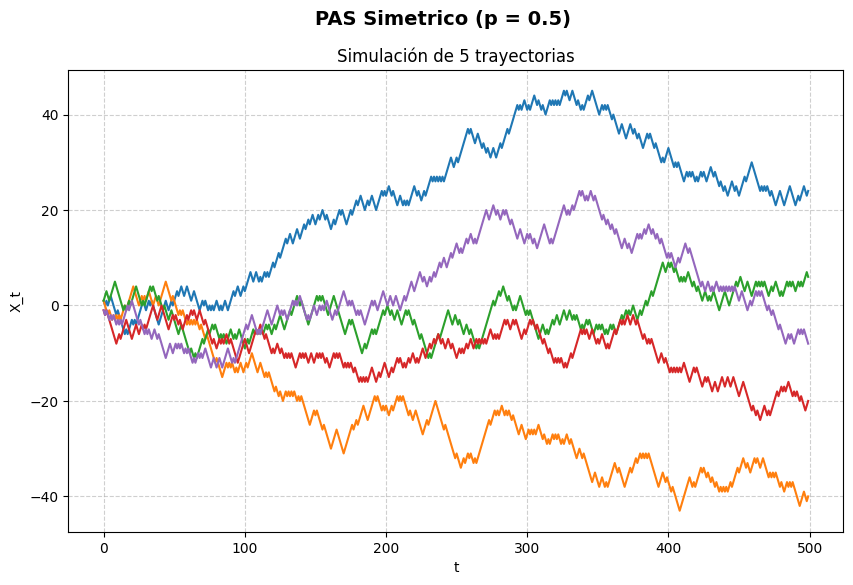

In [ ]:
# Simulación p=0.5 (misma probabilidad de subir y bajar)
tray1 = simular_PAS(0.5, n_pasos, num_trayectorias)
fig1 = dibujar_PAS(tray1)
plt.suptitle('PAS Simetrico (p = 0.5)', fontsize=14, fontweight='bold')
plt.show()

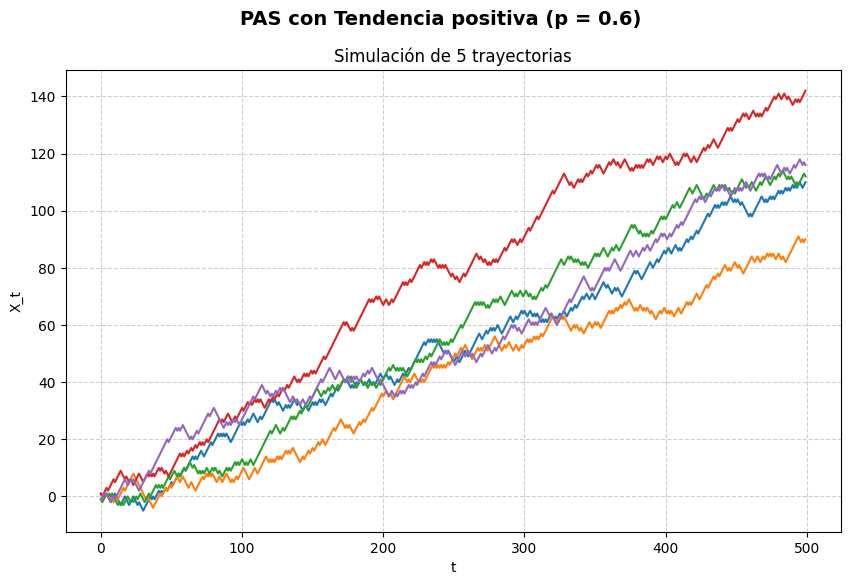

In [ ]:
# Simulación p=0.6 (tendencia a subir)
tray2 = simular_PAS(0.6, n_pasos, num_trayectorias)
fig2 = dibujar_PAS(tray2)
plt.suptitle('PAS con Tendencia positiva (p = 0.6)', fontsize=14, fontweight='bold')
plt.show()


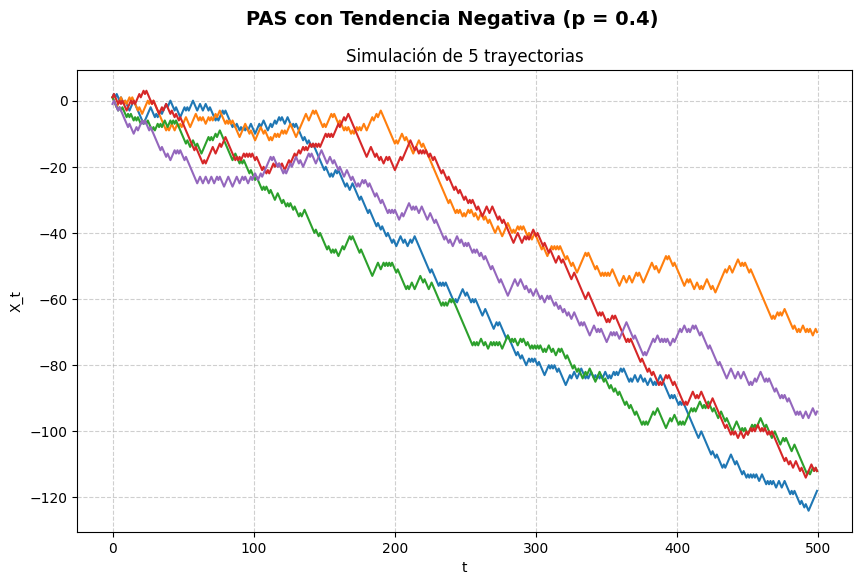

In [ ]:
# Simulacion p=0.4 (tendencia a bajar)
tray3 = simular_PAS(0.4, n_pasos, num_trayectorias)
fig3 = dibujar_PAS(tray3)
plt.suptitle('PAS con Tendencia Negativa (p = 0.4)', fontsize=14, fontweight='bold')
plt.show()


## **Función de medias del PAS**

En el instante $t = n$, la posición $X_n$ puede variar desde $-n$ hasta $n$, teniendo cada uno de estos valores una probabilidad asociada.
Para conocer la tendencia general de este proceso, calculamos su media teórica o valor esperado $E[X_n]$.

Aplicando que  paso independiente $Z_i$:
$$E[X_n] = E\left[ \sum_{i=1}^{n} Z_i \right] = \sum_{i=1}^{n} E[Z_i]
= n(2p - 1) $$

donde se ha aplicado que cada paso $Z_i$ es i.i.d y que su esperanza es $E[Z_i] = p - (1 - p) = 2p - 1$ pues vale $1$ (con probabilidad $p$) o $-1$ (con probabilidad $1 - p$).

**Análisis del comportamiento:**
Tal y como nos planteamos intuitivamente, la media depende directamente del instante de tiempo ($n$) y de la probabilidad de subir ($p$):
* **Si $p = 0.5$:** $E[X_n] = 0$ para cualquier $n \in \mathbb{N}$.
* **Si $p > 0.5$:** $E[X_n] > 0$, y el valor de la media crece con $n$.
* **Si $p < 0.5$:** $E[X_n] < 0$, y el valor de la media decrece con $n$.

## **Función de varianza del PAS**

Conocida la media teórica del PAS,  analizamos ahora su dispersión $t = n$. Para ello, calculamos su varianza teórica $Var[X_n]$.

Aplicando que cada paso $Z_i$ es independiente e idénticamente distribuido (i.i.d.):
$$
Var[X_n] = Var\left[ \sum_{i=1}^{n} Z_i \right] = \sum_{i=1}^{n} Var[Z_i] = n \cdot 4p(1 - p)
$$

donde se ha calculado la varianza de un único paso como $Var[Z_i] = E[Z_i^2] - (E[Z_i])^2 = 1 - (2p - 1)^2 = 4p(1 - p)$, ya que $E[Z_i^2] = 1^2 \cdot p + (-1)^2 \cdot (1 - p) = 1$.

**Análisis del comportamiento:**
Tal y como nos planteamos intuitivamente, la dispersión depende directamente del instante de tiempo ($n$) y de la probabilidad de subir ($p$):
* **Dependencia de $n$:** la varianza crece linealmente con el tiempo pues cuanto mayor número de pasos aumenta la acumulación de desviaciones posibles y por tanto la incertidumbre.
* **Dependencia de $p$:** La variabilidad es máxima en $p = 0.5$ (el movimiento más incierto pues la probabilidad de subir o bajar es la misma). Cuanto más se aleja $p$ de $0.5$, el movimiento está más determinado hacia una dirección concreta y la varianza disminuye.

## **Visualización de las trayectorias (con media y desviación típica teóricas)**

A continuación, visualizamos 20 trayectorias de un PAS para comprobar las propiedades del modelo matemático explicadas anteriormente. Para ello, superponemos al gráfico la **media teórica** y unas bandas de variabilidad basadas en la **desviación típica teórica** ($\sigma_n = \sqrt{Var[X_n]}$).

Específicamente, mostraremos:
* **La media teórica:** $E[X_n] = (2p-1)n$.
* **Bandas de dispersión:** Intervalos de $\pm 1$ y $\pm 2$ desviaciones típicas alrededor de la media.

In [ ]:
def dibujar_PAS_con_desviacion(trayectorias, p=0.5):
  """
  Función que dibuja las trayectorias de un PAS junto con su media teórica
  y bandas de dispersión (desviación típica).

  Args:
    trayectorias (ndarray): matriz de dimensiones (reps, n) con las posiciones acumuladas (X_n).
    p (float): probabilidad de dar un paso hacia arriba. Por defecto es 0.5 (simétrico).

  Return:
    fig (matplotlib.figure.Figure): objeto figura de Matplotlib con el gráfico generado.
  """

  # Figura base de Marplotlib
  fig = plt.figure(figsize=(10, 6))

  # Obtenemos el numero de trayectorias y el numero de pasos de la matriz de trayectorias
  reps, n = trayectorias.shape

  # Generamos T = N (0, 1, 2, ..., n-1)
  T = np.arange(n)

  # Calculamos la media y desviación típica teóricas
  media = T*(2*p-1) # array (1,n) de medias
  desv_tipica = np.sqrt(4*p*(1-p)*T) # array (1,n) de desviaciones tipicas

  #Dibujamos las trayectorias
  plt.plot(T,trayectorias.T) #plot interpreta los datos en columnas

  # Graficamos la media teórica previamente calculada
  plt.plot(T, media, color='black', linestyle='--', linewidth=2, label='Media teórica')

  # Sombrear ±1 y ±2 desviaciones típicas
  plt.fill_between(T, media - desv_tipica, media + desv_tipica, color='grey', alpha=0.3, label=r'$\pm 1 \sigma$')

  plt.fill_between(T, media - 2*desv_tipica, media + 2*desv_tipica, color='grey', alpha=0.1, label=r'$\pm 2 \sigma$')

  # Configuraciones del gráfico

  # Título
  plt.title(f'Simulación de {reps} trayectorias con bandas de dispersión teóricas') # titulo dinamico

  #Ejes
  plt.xlabel('t')
  plt.ylabel('X_t')

  # Activamos la leyenda
  plt.legend()

  # Cuadrícula
  plt.grid(True, linestyle='--', alpha=0.6) #cambiamos la transparencia con alpha


  return fig

In [ ]:
# Parámetros comunes
n_pasos=500
num_trayectorias=20

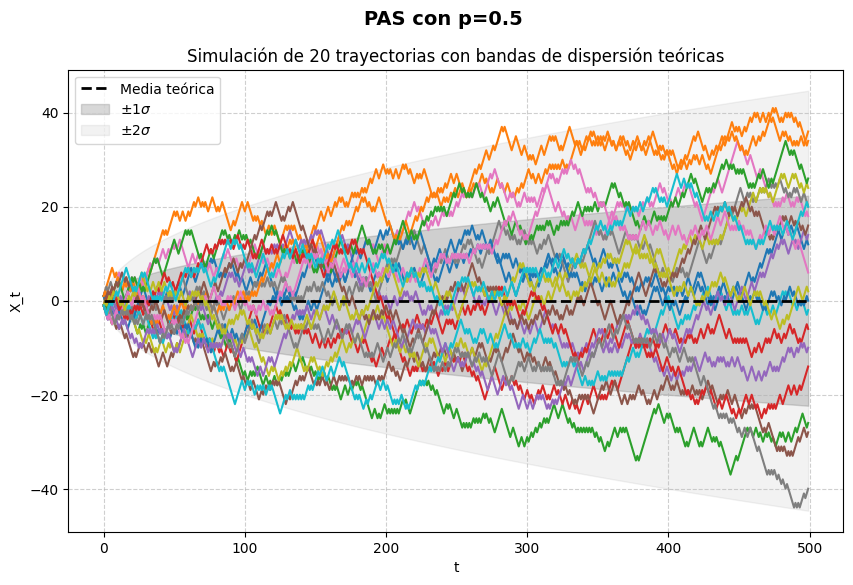

In [ ]:
# Simulación p=0.5 (misma probabilidad de subir y bajar)
p = 0.5
tray1 = simular_PAS(p, n_pasos, num_trayectorias)
fig1 = dibujar_PAS_con_desviacion(tray1,p)
plt.suptitle(f'PAS con p={p}', fontsize=14, fontweight='bold')
plt.show()

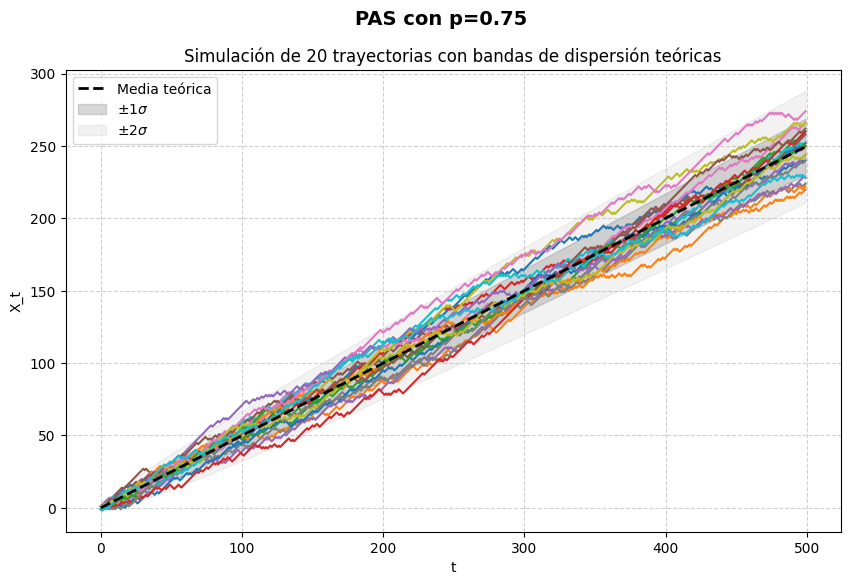

In [ ]:
# Simulación p=0.75 (tendencia positiva)
p = 0.75
tray2 = simular_PAS(p, n_pasos, num_trayectorias)
fig1 = dibujar_PAS_con_desviacion(tray2,p)
plt.suptitle(f'PAS con p={p}', fontsize=14, fontweight='bold')
plt.show()


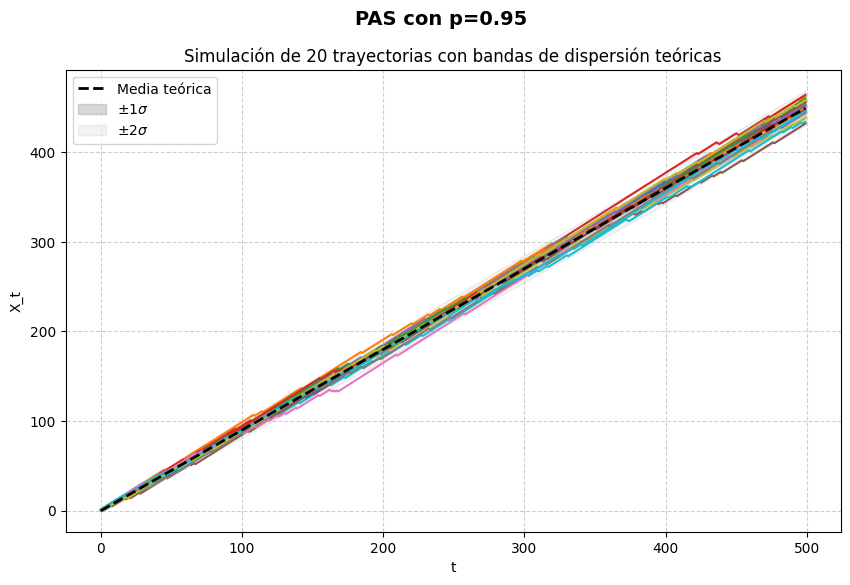

In [ ]:
# Simulación p=0.95 (tendencia muy positiva)
p = 0.95
tray3 = simular_PAS(p, n_pasos, num_trayectorias)
fig3 = dibujar_PAS_con_desviacion(tray3,p)
plt.suptitle(f'PAS con p={p}', fontsize=14, fontweight='bold')
plt.show()


## **Visualización de la media empírica junto con la media teórica**

En el siguiente gráfico, representa mos la media teórica junto con la empírica cuando promediamos varias trayectorias.

Claramente se aprecia como la media empírica, al aumentar el número de trayectorias, se aproxima a la teórica
$$E[X_n] = n(2p - 1) $$

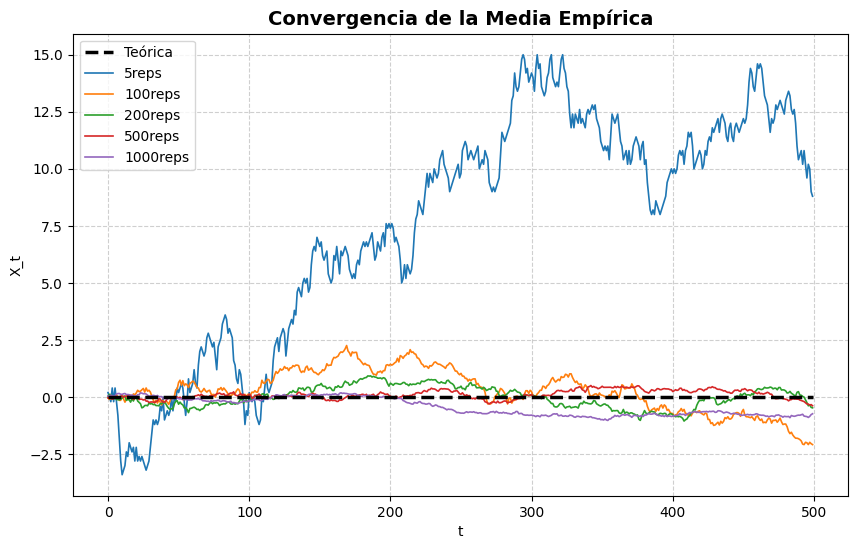

In [ ]:
# Parámetros
p=0.5
n_pasos=500
num_trayectorias=[5, 100, 200, 500, 1000]

# Figura base de Matplotlib
fig = plt.figure(figsize=(10, 6))

# Generamos T = N (0, 1, 2, ..., n-1)
T = np.arange(n_pasos)

# Calculamos y ploteamos la media teórica para cada instante
media_teorica = T*(2*p-1) # array (1,n) de medias
plt.plot(T, media_teorica, color='black', linestyle='--', linewidth=2.5, label='Exact', zorder=10)

# Calculamos  y ploteamos la media empírica para cada simulacion de 'reps' trayectorias
for i in num_trayectorias:
  tray = simular_PAS(p, n_pasos, i)
  media_empirica = np.mean(tray, axis=0)
  plt.plot(T, media_empirica, linewidth=1.2, label=f'{i}reps')

# Configuraciones del gráfico

# Título
plt.title('Convergencia de la Media Empírica', fontsize=14, fontweight='bold')

#Ejes
plt.xlabel('t')
plt.ylabel('X_t')

# Activamos la leyenda
plt.legend()

# Cuadrícula
plt.grid(True, linestyle='--', alpha=0.6) #cambiamos la transparencia con alpha

plt.show()

## **Referencias**

Toda la teoría, fórmulas y definiciones que he utilizado como referencia para programar estas simulaciones del PAS provienen de:
* **Morales Álvarez, P.** (*s.f.*). *Tema 1: Teoría general de Procesos Estocásticos. Algunos ejemplos* [Diapositivas de clase]. Universidad de Granada.